# Gene-Specific Velocity Dynamics
CellDyc was applied to mouse gastrulation erythroid maturation (See details <span style="color: darkblue;">[here](datasets.rst#celldyc.datasets.core.gastrulation)</span>). CellDyc resolves gene-specific velocity dynamics in the expression-time space.


## Import Packages

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import celldyc as cdc

## Load the Data
The analysis is based on in-built mouse gastrulation erythroid maturation dataset.

In [ ]:
adata = cdc.datasets.gastrulation()
adata

AnnData object with n_obs × n_vars = 12324 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'celltype_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

This dataset contains erythroid cells from 8 developmental time points (E6.75–E8.5).

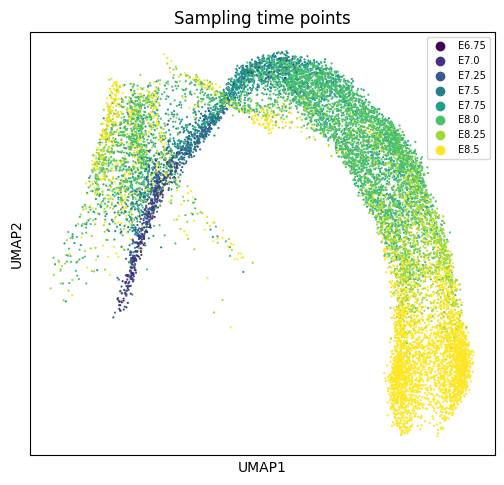

In [4]:
fig, ax = plt.subplots(figsize=(6,5.5))
ax = sc.pl.embedding(
    adata,
    color=["stage"],
    basis="umap",
    ax=ax,
    legend_loc="upper right",
    palette="viridis",legend_fontsize=7,title="Sampling time points"
)

## Preprocess the Data

In [5]:
adata = cdc.tl.preprocess(adata)
adata

AnnData object with n_obs × n_vars = 12324 × 2000
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'stage_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

We transform descriptive time point strings into numerical format.

In [6]:
cat_map = {
    'E6.75': 6.75,
    'E7.0': 7.0,
    'E7.25': 7.25,
    'E7.5': 7.5,
    'E7.75': 7.75,
    'E8.0': 8.0,
    'E8.25': 8.25,
    'E8.5': 8.5,
}
adata.obs['numerical_time'] = adata.obs['stage'].map(cat_map).astype('category')

We reordered the cell-type categories so that “Haematoendothelial progenitors” receives the first color in the palette.

In [7]:
adata.obs['celltype'] = adata.obs['celltype'].cat.reorder_categories(
    ['Haematoendothelial progenitors'] + 
    [cat for cat in adata.obs['celltype'].cat.categories 
     if cat != 'Haematoendothelial progenitors']
)
adata.uns['celltype_colors'] = cdc.settings.colormap["gastrulation"]

## Estimation of Time Representation and Transcriptomic Velocity

Train CellDyc using the `recover_dyc` function. By default, predicted velocties are stored in **adata.layers['velocity']**, and predicted time values are stored in **adata.obs['getime']**.

In [8]:
cdc.tl.recover_dyc(adata, time_key='numerical_time')

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.864613,trend_loss=0.851177,time_loss=0.134356
epoch  51:loss=0.667414,trend_loss=0.661974,time_loss=0.054399
epoch 101:loss=0.656995,trend_loss=0.651533,time_loss=0.054617
epoch 151:loss=0.657527,trend_loss=0.652122,time_loss=0.054050
epoch 201:loss=0.652532,trend_loss=0.647125,time_loss=0.054069
epoch 251:loss=0.650788,trend_loss=0.645402,time_loss=0.053857
epoch 301:loss=0.649185,trend_loss=0.643784,time_loss=0.054010
Early stopping at epoch 318


AnnData object with n_obs × n_vars = 12324 × 2000
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'numerical_time', 'getime'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'getime_weights'
    uns: 'celltype_colors', 'stage_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'velocity'
    obsp: 'distances', 'connectivities'

We compare original sampling time points and learned gene-emdedded time distributions; the latter faithfully mirrors the former across all lineages.
- Left Panel: Violin plots of original sampling time across cell types.
- Right Panel: Violin plots of learned gene-embedded time across cell types.

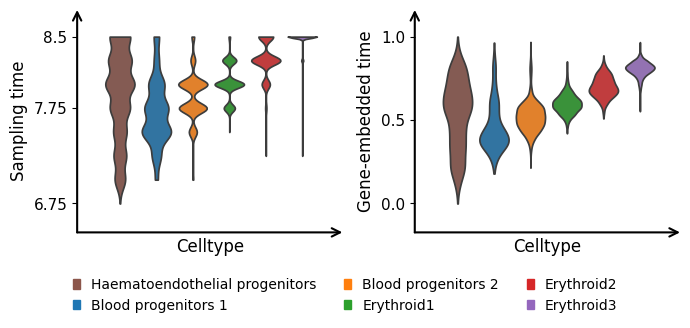

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7,3))
cdc.pl.getime_violin(
    adata, 
    'numerical_time', 
    'celltype', 
    palette=adata.uns['celltype_colors'],
    xlabel="Celltype", 
    ylabel="Sampling time",
    ax=axes[0]  
)
cdc.pl.getime_violin(
    adata, 
    'getime', 
    'celltype', 
    palette=adata.uns['celltype_colors'],
    xlabel="Celltype", 
    ylabel="Gene-embedded time",
    ax=axes[1]  
)
handles = [mpatches.Patch(color=c, label=l)
           for l,c in zip(adata.obs['celltype'].cat.categories, adata.uns['celltype_colors'].values())]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,handlelength=0.5,bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(rect=[0,0.08,1,1])
plt.show()

We then project the velocities onto the umap embedding.

  0%|          | 0/12324 [00:00<?, ?cells/s]

computing velocity graph
finished.


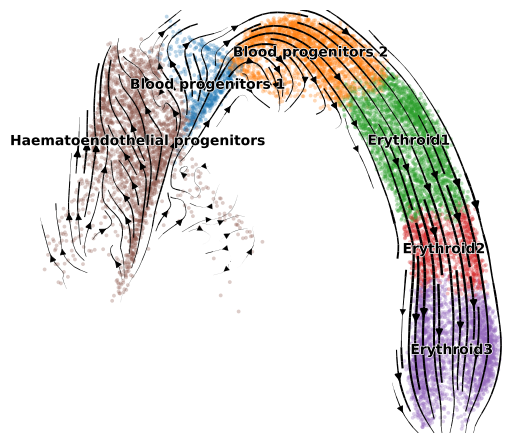

computing velocity embedding
finished.


In [10]:
cdc.pl.plot_velocity_projection(adata, color='celltype', figsize=(6, 5.5), size=30)

## Gene-Specific Velocities Analysis

We use the `velocity_hot` function to plot single-gene velocities on the UMAP embedding, using values from **adata.layers['velocity']**.

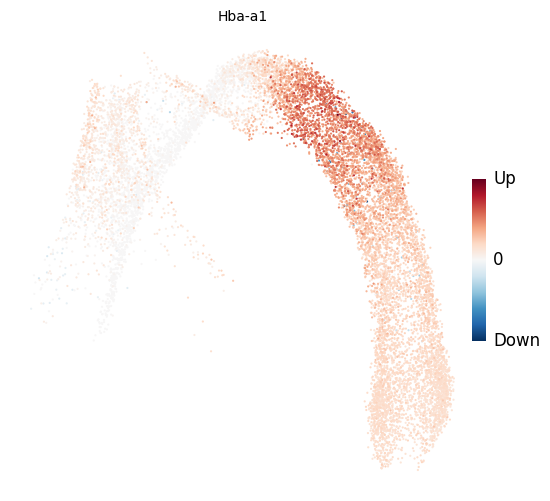

(<Figure size 600x600 with 2 Axes>, <Axes: title={'center': 'Hba-a1'}>)

In [11]:
gene = 'Hba-a1'
cdc.pl.velocity_hot(adata=adata, gene=gene)


The `velocity_dynamics` visualizes the dynamics in expression-time space. Expression levels (y-axis) are plotted against gene-embedded time (x-axis), with arrows depicting the velocities.

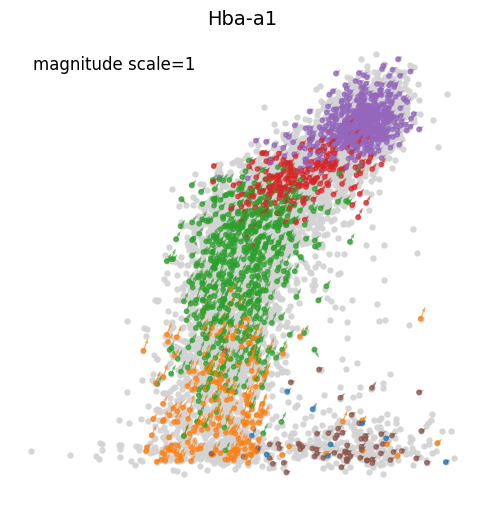

In [12]:
cdc.pl.velocity_dynamics(adata, gene_name=gene,figsize=(6,6))